In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import SBVGPResult, SIResult, FlowPriorResult
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors 
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl

import torch
import matplotlib.pyplot as plt
import seaborn as sns


torch.manual_seed(42)

[2024-06-25 09:22:59,703][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-06-25 09:22:59,799][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
best_prior = FlowPriorResult.fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]

In [3]:
best_si = SIResult.fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]
best_sbv = SBVGPResult.fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]

In [4]:
best_prior

{'fp_id': '89c1053a65023b042dc63f7f852bb5b0',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -51.37348556518555,
 'train_ll_sem': 1.190269112586975,
 'val_ll_mean': -51.278499603271484,
 'val_ll_sem': 2.2305781841278076,
 'test_ll_mean': -51.278499603271484,
 'test_ll_sem': 2.2305781841278076,
 'tracker_output': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_model.pt'}

In [5]:
best_si_model = torch.load(best_si["model"], map_location="cpu")
best_sbv_model = torch.load(best_sbv["model"], map_location="cpu")
best_prior_model = torch.load(best_prior["model"], map_location="cpu")

In [6]:
train_logls = [best_si["train_ll_mean"], best_sbv["train_ll_mean"], best_prior["train_ll_mean"]]
val_logls = [best_si["val_ll_mean"], best_sbv["val_ll_mean"], best_prior["val_ll_mean"]]
test_logls = [best_si["test_ll_mean"], best_sbv["test_ll_mean"], best_prior["test_ll_mean"]]

train_logls_sems = [best_si["train_ll_sem"], best_sbv["train_ll_sem"], best_prior["train_ll_sem"]]
val_logls_sems = [best_si["val_ll_sem"], best_sbv["val_ll_sem"], best_prior["val_ll_sem"]]
test_logls_sems = [best_si["test_ll_sem"], best_sbv["test_ll_sem"], best_prior["test_ll_sem"]]

Text(0.5, 1.0, 'Posterior model comparison')

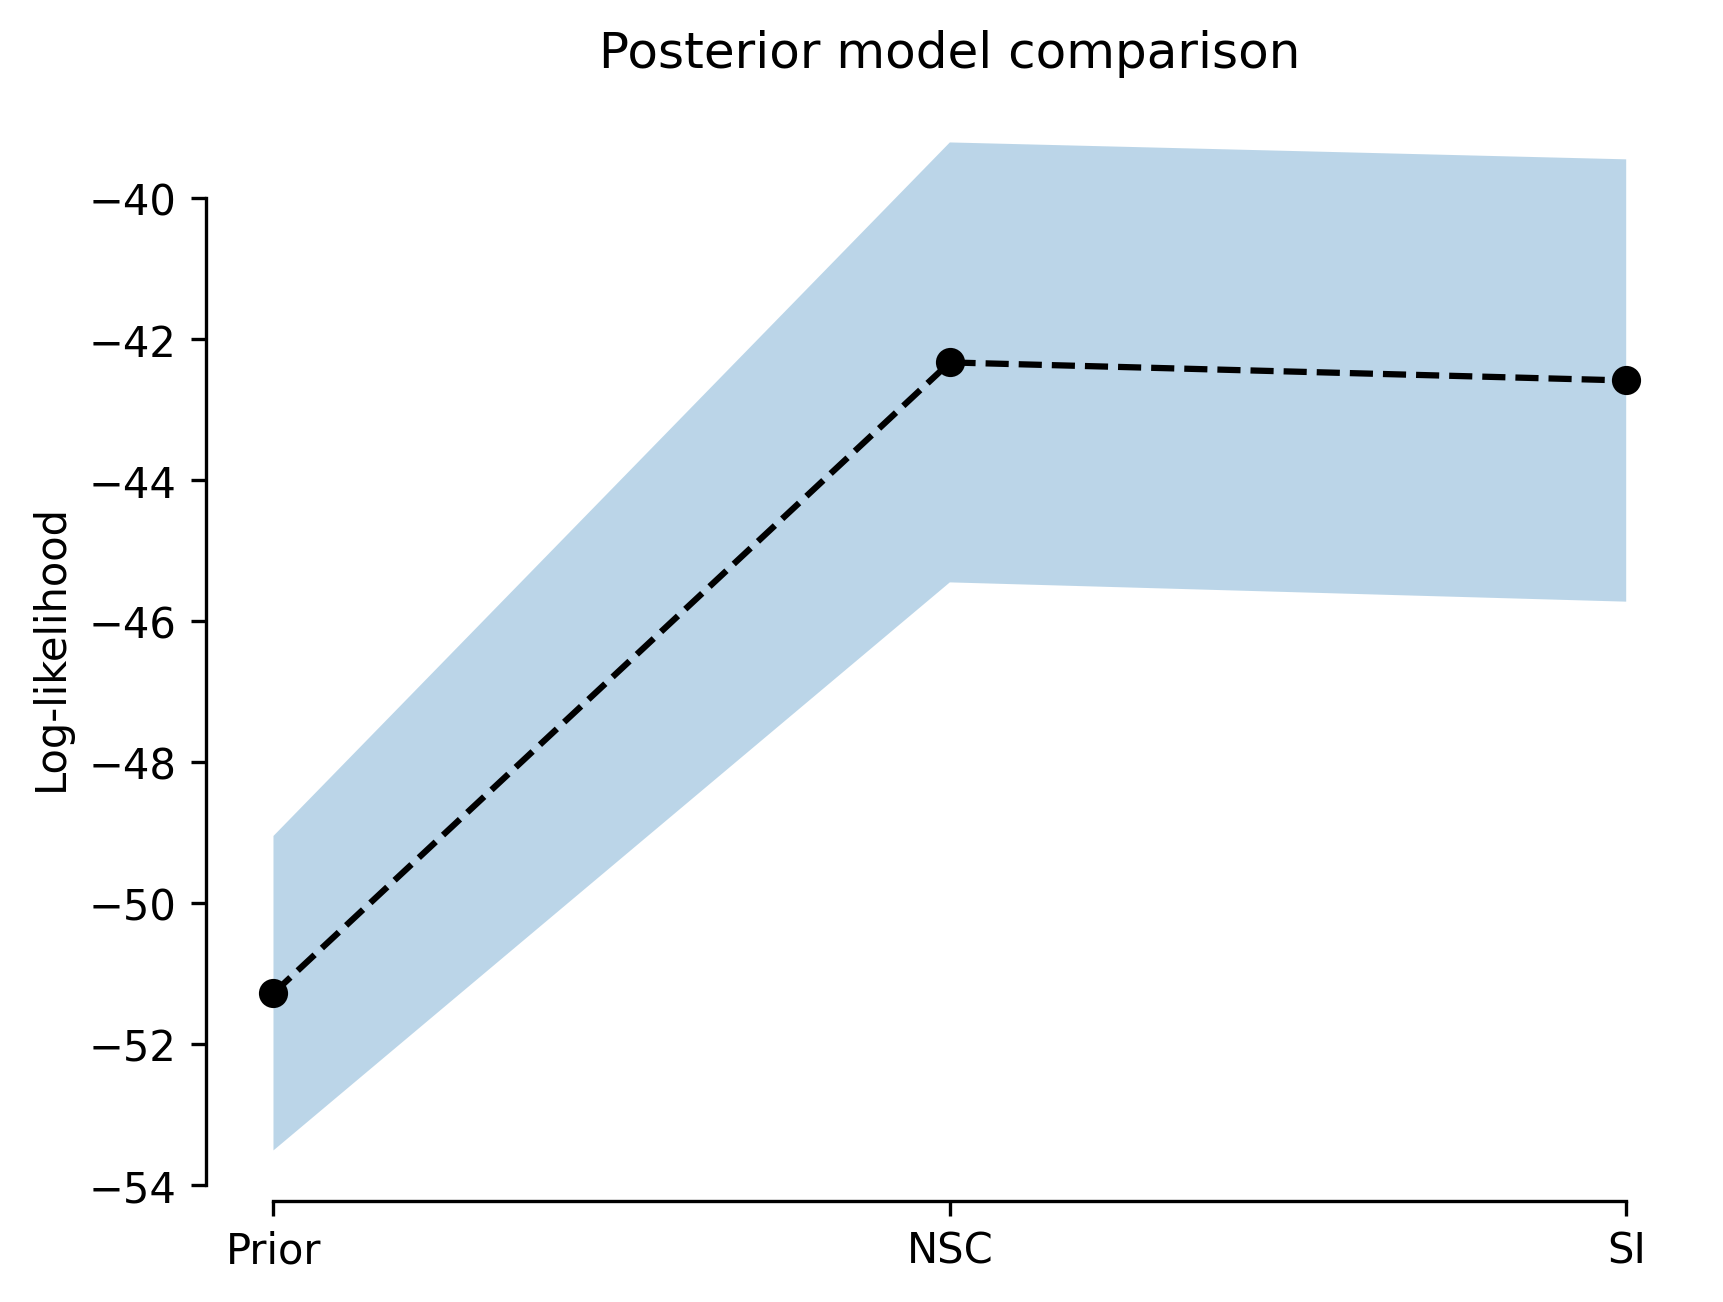

In [7]:
fig, ax = plt.subplots(dpi=300)
x = ["Prior", "NSC", "SI"]
# ax.plot(x, train_logls[::-1])
# ax.fill_between(x, [train_logls[i] - train_logls_sems[i] for i in range(3)][::-1], [train_logls[i] + train_logls_sems[i] for i in range(3)][::-1], alpha=0.3)
# ax.plot(x, val_logls[::-1], color="black", marker="o", linestyle="--")
# ax.fill_between(x, [val_logls[i] - val_logls_sems[i] for i in range(3)][::-1], [val_logls[i] + val_logls_sems[i] for i in range(3)][::-1], alpha=0.3)
ax.plot(x, test_logls[::-1], color="black", marker="o", linestyle="--")
ax.fill_between(x, [test_logls[i] - test_logls_sems[i] for i in range(3)][::-1], [test_logls[i] + test_logls_sems[i] for i in range(3)][::-1], alpha=0.3)
sns.despine(ax=ax, trim=True)
ax.set_ylabel("Log-likelihood")
ax.set_title("Posterior model comparison")

In [8]:
data_loader_args = (DataLoaderConfig & {"id": best_si["dl_id"]}).fetch1()
data_loader_args

{'id': '260a5ea8175f75eaef132f42873ad14a',
 'data_fname': '/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl',
 'train_prop': 0.7,
 'val_prop': 0.2}

In [9]:
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=data_loader_args["data_fname"],
    train_prop=data_loader_args["train_prop"],
    val_prop=data_loader_args["val_prop"],
    batch_size=128,
)

In [10]:
train_lp_prior, _ = compute_logl(
    model=best_prior_model,
    data_loader=train_loader,
    data_dim=0,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)
val_lp_prior, _ = compute_logl(
    model=best_prior_model,
    data_loader=val_loader,
    data_dim=0,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)
test_lp_prior, _ = compute_logl(
    model=best_prior_model,
    data_loader=test_loader,
    data_dim=0,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)

train_lp_si, _ = compute_logl(
    model=best_si_model,
    data_loader=train_loader,
    data_dim=0,
    cond_dim=1,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)
val_lp_si, _ = compute_logl(
    model=best_si_model,
    data_loader=val_loader,
    data_dim=0,
    cond_dim=1,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)
test_lp_si, _ = compute_logl(
    model=best_si_model,
    data_loader=test_loader,
    data_dim=0,
    cond_dim=1,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)

train_lp_sbv, _ = compute_logl(
    model=best_sbv_model,
    data_loader=train_loader,
    data_dim=0,
    cond_dim=1,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)
val_lp_sbv, _ = compute_logl(
    model=best_sbv_model,
    data_loader=val_loader,
    data_dim=0,
    cond_dim=1,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)
test_lp_sbv, _ = compute_logl(
    model=best_sbv_model,
    data_loader=test_loader,
    data_dim=0,
    cond_dim=1,
    device="cpu",
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="bits",
)

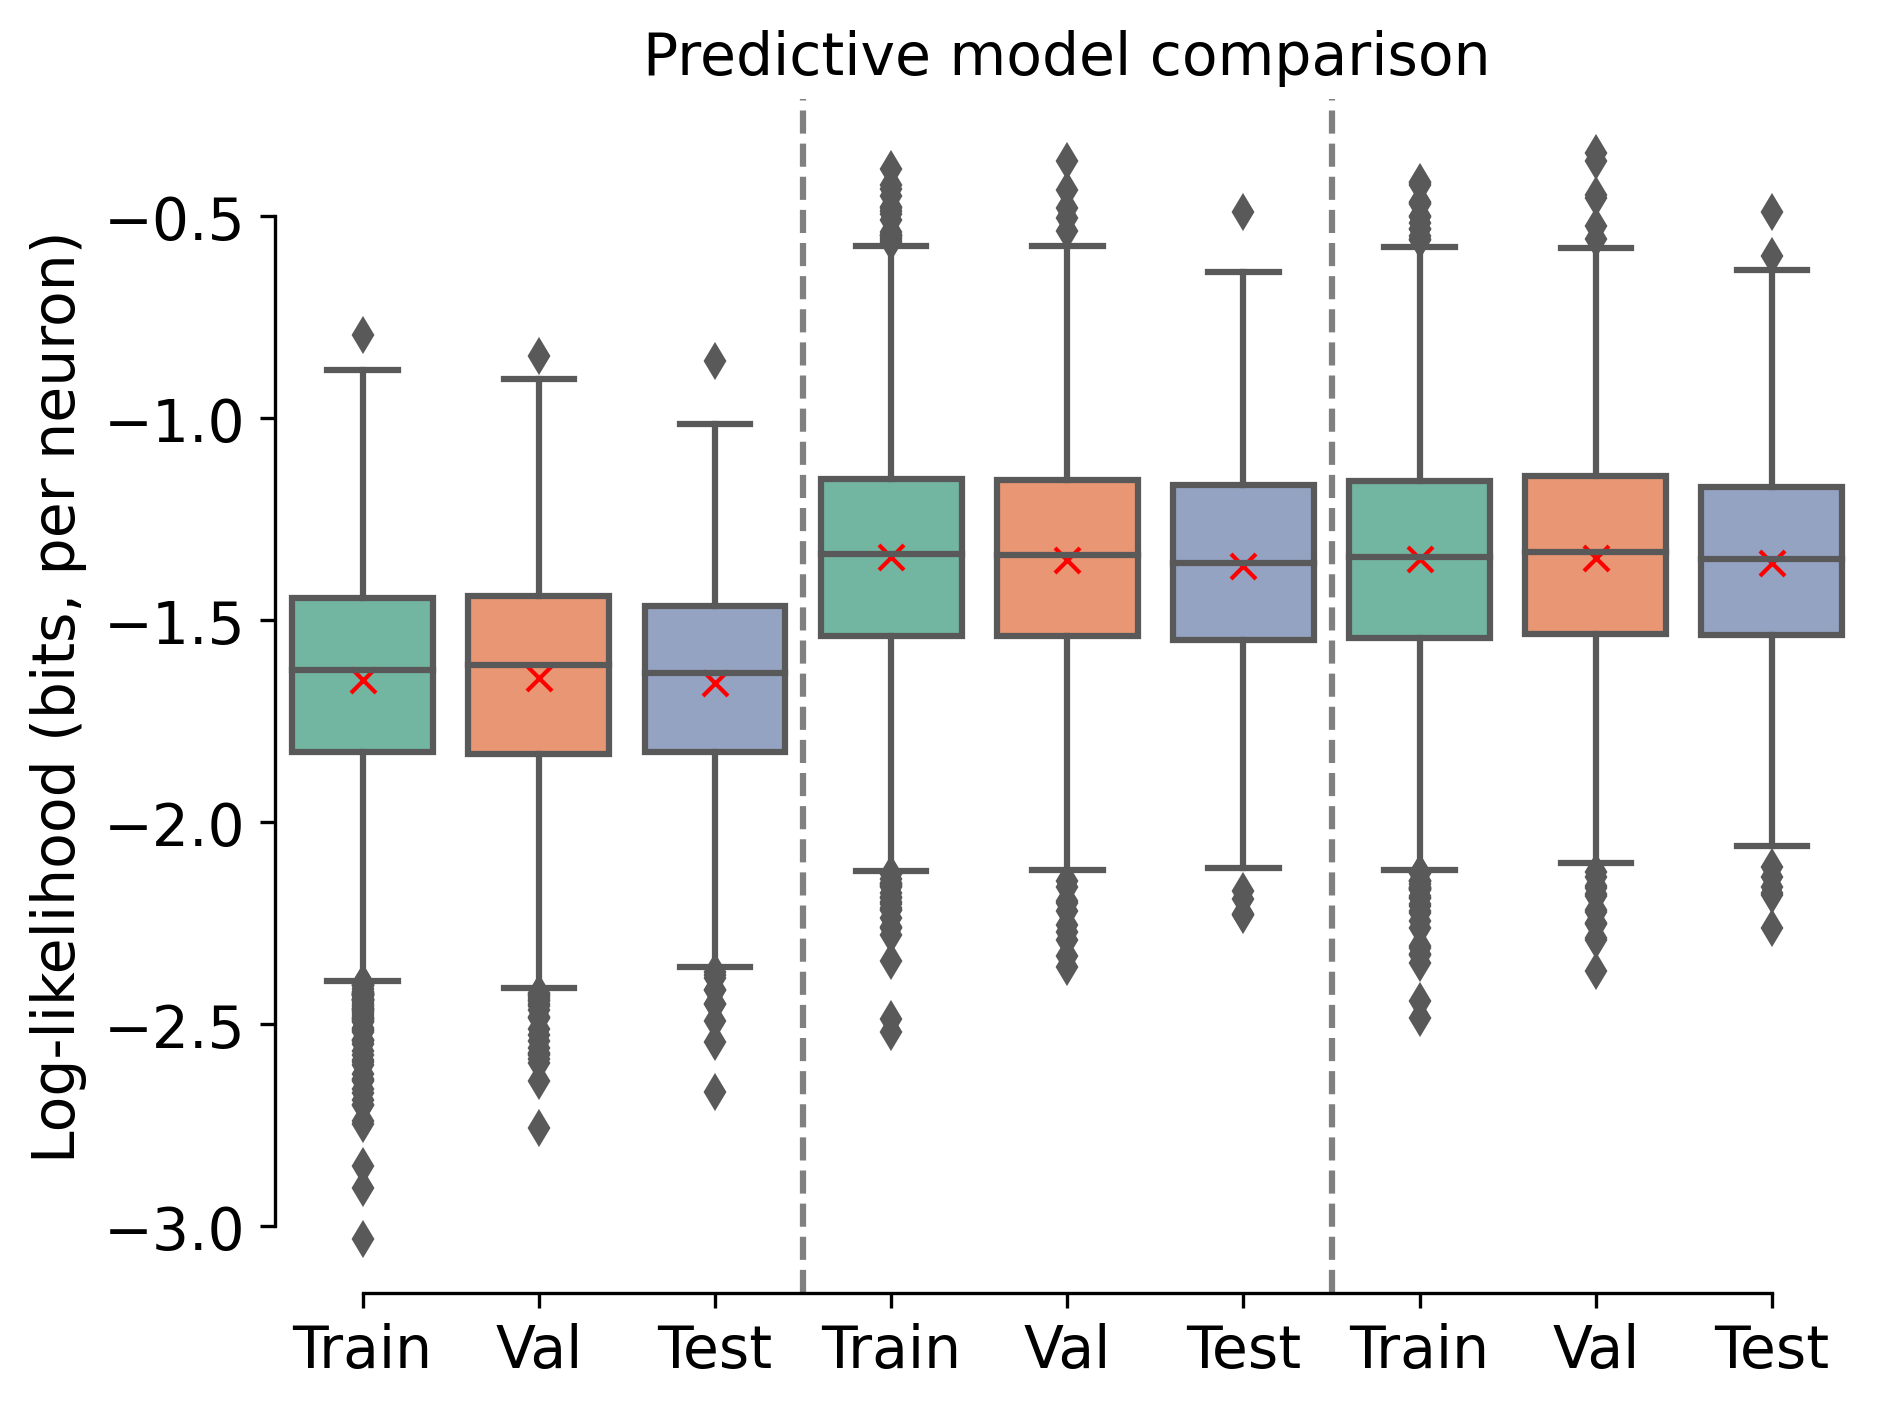

In [23]:
data = [
    train_lp_prior,
    val_lp_prior,
    test_lp_prior,
    train_lp_si,
    val_lp_si,
    test_lp_si,
    train_lp_sbv,
    val_lp_sbv,
    test_lp_sbv,
]
labels = [
    "Train",
    "Val",
    "Test",
    "Train",
    "Val",
    "Test",
    "Train",
    "Val",
    "Test",
]
palette = ["#66c2a5", "#fc8d62", "#8da0cb"] * 3

# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
ax = sns.boxplot(data=data, palette=palette)
# add mean values
for i, value in enumerate(data):
#     ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
#     # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels)
ax.set_title("Predictive model comparison", fontsize=14)
ax.set_ylabel("Log-likelihood (bits, per neuron)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# Display the plot
plt.show()

# Inspecting the predictive models

## Creating stimuli

In [8]:
orientations = torch.linspace(0, torch.pi, steps=45 + 1)[:-1]
# orientations = torch.linspace(0, torch.pi, steps=45 + 1)[:-1][::11]
obs_h, obs_w = 12, 12
gabor_params = dict(
    {
        "canvas_size": [obs_h, obs_w],
        "sizes": [10],
        "spatial_frequencies": [1 / 3],
        "contrasts": [1.0],
        "grey_levels": [0.0],
        "eccentricities": [0.0],
        "locations": [[6, 6]],
        "phases": [torch.pi / 2],
        "relative_sf": False,
    },
)
stimuli = torch.Tensor(
    generate_gabors(orientations=orientations.tolist(), gabor_params=gabor_params)
)

In [9]:
# fig, axs = plt.subplots(1, 5, dpi=300)
# for i, ax in enumerate(axs.flatten()):
#     ax.imshow(stimuli[i].numpy(), cmap="gray")
#     ax.axis("off")

In [10]:
import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

def plot_predictive_means_and_task_prior(
    means,
    task_params = {
        "orientations": torch.linspace(0, np.pi, steps=45 + 1)[:-1],
        "c1_psi" : np.pi / 4,
        "c2_psi" : 3 * np.pi / 4,
    },
    plotting_params = {
        "dpi": 300,
        "bar_color": "olivedrab",
        "bar_edgecolor": "black",
        "fontsize": 16,
        "linewidth": 4,
        "tick_length": 6,
        "tick_width": 2,
        "save_path": "/tmp.pdf",
        "label": "Avg firing rate $x_i$",
        "legend": False,
        "legend_loc": "upper right",
        "legend_fontsize": 16,
    }
):
    all_orientations = torch.linspace(0, torch.pi, steps=1000)
    c1_orientation_density = cos2_von_mises(all_orientations, task_params["c1_psi"], 1.0)
    c2_orientation_density = cos2_von_mises(all_orientations, task_params["c2_psi"], 1.0)
    prior = 0.5 * c1_orientation_density + 0.5 * c2_orientation_density
    fig, ax = plt.subplots(dpi=plotting_params['dpi'])
    xticks = np.array([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_xticks(xticks)
    ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
    ax.set_xlabel("Orientation preference $\\psi^x$ ($^\circ$)", fontsize=plotting_params["fontsize"])
    ax.bar(
        orientations,
        means,
        width=np.pi / len(orientations),
        color=plotting_params["bar_color"],
        edgecolor=plotting_params["bar_edgecolor"],
        label=plotting_params["label"],
    )
    ax.plot(
        all_orientations,
        prior,
        color="orange",
        linestyle="--",
        label="Prior $\\theta$",
        linewidth=plotting_params["linewidth"],
    )
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=plotting_params["fontsize"],
        length=plotting_params["tick_length"],
        width=plotting_params["tick_width"],
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Avg firing rate", fontsize=plotting_params["fontsize"])
    sns.despine(ax=ax, trim=True)
    ax.spines[["left", "bottom"]].set_visible(True)
    ax.spines[["left", "bottom"]].set_linewidth(plotting_params["tick_width"])
    if plotting_params["legend"]:
        ax.legend(loc=plotting_params["legend_loc"], fontsize=plotting_params["legend_fontsize"])
    fig.savefig(plotting_params["save_path"], bbox_inches="tight")
    plt.close(fig)

In [11]:
plotting_params = {
    "dpi": 300,
    "bar_color": "olivedrab",
    "bar_edgecolor": "black",
    "fontsize": 16,
    "linewidth": 4,
    "tick_length": 6,
    "tick_width": 2,
    "save_path": "/tmp.pdf",
    "label": "Avg firing rate $x_i$",
    "legend": False,
    "legend_loc": "upper right",
    "legend_fontsize": 16,
}

si_plotting_params = plotting_params.copy() 
si_plotting_params.update({"bar_color": "olivedrab"})
sbv_plotting_params = plotting_params.copy()
sbv_plotting_params.update({"bar_color": "teal"})

task_params = dict(
    orientations = torch.linspace(0, np.pi, steps=45 + 1)[:-1],
    c1_psi = np.pi / 4,
    c2_psi = 3 * np.pi / 4,
)

# with torch.no_grad():
#     best_si_model.eval()
#     best_sbv_model.eval()
#     for stimulus, orientation in zip(stimuli, task_params["orientations"]):
#         stimulus = stimulus.flatten()
#         si_dist = best_si_model.trainable_distribution.distribution(cond=stimulus)
#         si_mean = si_dist.base_dist.concentration / si_dist.base_dist.rate
#         si_plotting_params.update(
#             {
#                 "save_path": f"/src/project/figures/learning/predictive/si/{int(np.rad2deg(orientation))}.pdf"
#             }
#         )
#         plot_predictive_means_and_task_prior(
#             si_mean, 
#             task_params, 
#             si_plotting_params
#         )
#         sbv_dist = best_sbv_model.trainable_distribution.distribution(cond=stimulus)
#         sbv_mean = sbv_dist.base_dist.mean
#         sbv_plotting_params.update(
#             {
#                 "save_path": f"/src/project/figures/learning/predictive/sbv/{int(np.rad2deg(orientation))}.pdf"
#             }
#         )
#         plot_predictive_means_and_task_prior(
#             sbv_mean, 
#             task_params, 
#             sbv_plotting_params
#         )
        # break

In [13]:
def plot_predictive_dist(si_dist, sbv_dist, task_params, plotting_params):
    zero = torch.finfo(torch.float32).eps
    x = torch.linspace(zero, 6, steps=1000).unsqueeze(-1).repeat(1, 45)
    si_pdf = si_dist.log_prob(x).exp()
    sbv_pdf = sbv_dist.log_prob(x).exp()
    fig, axs = plt.subplots(
        7, 7, dpi=plotting_params["dpi"], sharex=True, sharey=True, tight_layout=True
    )
    for i, ax in enumerate(axs.flatten()):
        if i >= 45:
            ax.axis("off")
            continue
        ax.plot(
            x[:, i].numpy(),
            si_pdf[:, i].numpy(),
            color=plotting_params["si_color"],
            linewidth=plotting_params["linewidth"],
            alpha=plotting_params["si_alpha"],
        )
        ax.fill_between(
            x[:, i].numpy(),
            si_pdf[:, i].numpy(),
            color=plotting_params["si_color"],
            alpha=plotting_params["si_alpha"],
            label="SI",
        )
        ax.plot(
            x[:, i].numpy(),
            sbv_pdf[:, i].numpy(),
            color=plotting_params["sbv_color"],
            linestyle="dashed",
            linewidth=plotting_params["linewidth"],
            alpha=plotting_params["sbv_alpha"],
            label="NSC",
        )
        ax.set_xlim(*plotting_params["xlim"])
        ax.set_ylim(*plotting_params["ylim"])
        ax.yaxis.set_visible(False)
        ax.spines[["top", "bottom", "left", "right"]].set_visible(False)
        ax.text(
            0.7,
            0.9,
            f"$\\Psi^x=${int(np.rad2deg(task_params['orientations'][i]))}$^\circ$",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
            fontsize=plotting_params["fontsize"],
        )
        # ax.axis("off")
    if plotting_params["legend"]:
        handles, labels = axs.flatten()[0].get_legend_handles_labels()
        fig.legend(
            handles, labels, loc="lower right", fontsize=plotting_params["legend_fontsize"]
        )
    fig.supxlabel("Posterior firing rate")
    fig.supylabel("Density")
    fig.savefig(plotting_params["save_path"], bbox_inches="tight")
    plt.close(fig)

In [15]:
plotting_params = {
    "dpi": 300,
    "si_color": "peru",
    "si_alpha": 0.8,
    "sbv_color": "teal",
    "sbv_alpha": 1.0,
    "fontsize": 6,
    "linewidth": 2,
    "tick_length": 6,
    "tick_width": 2,
    "save_path": "/tmp.pdf",
    "xlabel": "Firing rate of $x_i$",
    "xlim": [-0.5, 3],
    "ylim": [0, 5],
    "legend": True,
    "legend_loc": "lower right",
    "legend_fontsize": 10,
}


with torch.no_grad():
    best_si_model.eval()
    best_sbv_model.eval()
    for stimulus, orientation in zip(stimuli, task_params["orientations"]):
        stimulus = stimulus.flatten()
        si_dist = best_si_model.trainable_distribution.distribution(cond=stimulus).base_dist
        sbv_dist = best_sbv_model.trainable_distribution.distribution(cond=stimulus).base_dist
        plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/si_sbv_dists_{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_dist(
            si_dist, sbv_dist, task_params, plotting_params
        )

In [16]:
si_dist

Gamma(concentration: torch.Size([45]), rate: torch.Size([45]))

In [17]:
zero = torch.finfo(torch.float32).eps
x = torch.linspace(zero, 6, steps=1000).unsqueeze(-1).repeat(1, 45)
si_pdf = si_dist.log_prob(x).exp()
sbv_pdf = sbv_dist.log_prob(x).exp()

In [18]:
plotting_params = {
    "dpi": 300,
    "si_color": "peru",
    "si_alpha": 0.8,
    "sbv_color": "teal",
    "sbv_alpha": 1.0,
    "fontsize": 6,
    "linewidth": 2,
    "tick_length": 6,
    "tick_width": 2,
    "save_path": "/tmp.pdf",
    "xlabel": "Firing rate of $x_i$",
    "xlim": [-0.5, 3],
    "ylim": [0, 5],
    "legend": True,
    "legend_loc": "lower right",
    "legend_fontsize": 10,
}

